# A problem + ML pipeline

**An end-to-end introduction to incorporating ML to research**

The first notebook introduced NN for function fitting (ML for a single task). This notebook covers elements that surround this, including:

> Messy data. It has to be cleaned, split, and scaled before being used by
> a model. We also set up a baseline to beat, if our approach can't beat it,
> then it is not very good.

We will build one small pipeline, end to end, and we will use synthetic
(but realistic) data to illustrate concepts:

| Stage | Key idea |
|---|---|
| 1. Data generation | Creating  |
| 2. Data curation | Can we use all the data? |
| 3. Preprocessing | Preparing the data to be used |
| 4. Baseline selection | What score should "good" beat? |
| 5. Model training | Fit the model in a full set with a **DataLoader**, properly batched |
| 6. Schedulers & stopping | Updating the learning rate and early stopping |
| 7. Evaluation | How to assess our model |

The running example is a small binary classification problem: two interleaved
"moons" of points.

**Prerequisites:** notebook 1 (training loops, loss, gradient descent), and basic
pandas / NumPy. We also use sklearn, which is a very useful library for data manipulation.

In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

torch.manual_seed(0)
rng = np.random.default_rng(0)

# Same visual language throughout: each colour is one identity, everywhere it appears.
C_CLASS0  = "#2a78d6"   # class 0
C_CLASS1  = "#eb6834"   # class 1
C_FLAG    = "#d03b3b"   # a record flagged during curation (status colour, not a class)
C_TRUTH   = "#0b0b0b"   # decision boundary / ground truth
C_MAJORITY= "#8a8983"   # majority-class baseline (deliberately "no model" grey)
C_LOGREG  = "#2a78d6"   # logistic regression baseline
C_MLP     = "#1baf7a"   # the neural network
# scheduler comparison (4 series, fixed categorical order)
C_CONST, C_STEP, C_COS, C_PLATEAU = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"

plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#c9c8c4", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 2.0, "font.size": 11, "legend.frameon": False,
})

print("torch", torch.__version__, "| pandas", pd.__version__)

torch 2.7.0 | pandas 2.3.1


---
# 1. Data generation

ML applications typically rely on loads of data. Here we *generate* it, which has one great advantage of knowing exactly what the data is. Note that in some projects, this might already be the case, so that some of the steps here can be skipped. In others, the data might come from external datasets and then some more thorough investigation is required.

We start from a clean, well-behaved data (two intersecting "moons") and add some issues to the data:

* **label noise**: a few annotations are simply wrong (human error, sensor glitch),
* **missing values**: a sensor occasionally drops a reading,
* **duplicate rows**: a logging bug double-writes some records,
* **outliers**: a handful of corrupted or out-of-range records.

These are some of the issues we can expect with real-world data. 

Note that we are using `pandas` here to treat the data for simplicity, but this is not explicitly required.

In [9]:
N_CLEAN = 600
X0, y0 = make_moons(n_samples=N_CLEAN, noise=0.20, random_state=0)
y0 = y0.astype(int)

# Shuffle once and carve out disjoint index blocks, so the corruptions below
# never collide with each other (a duplicated row is never also a missing row).
perm = rng.permutation(N_CLEAN)
flip_idx = perm[:24]          # ~4% label noise
miss_idx = perm[24:39]        # 15 rows will lose a feature
dup_idx  = perm[39:59]        # 20 rows will be double-logged

y_noisy = y0.copy()
y_noisy[flip_idx] = 1 - y_noisy[flip_idx]

df = pd.DataFrame({"x1": X0[:, 0], "x2": X0[:, 1], "label": y_noisy})
df.loc[miss_idx, "x1"] = np.nan          # missingness happens BEFORE duplication,
df = pd.concat([df, df.loc[dup_idx]], ignore_index=True)   # so a duplicated row
                                                             # carries its NaN too

n_out = 10
out_x1 = rng.choice([-1.0, 1.0], n_out) * rng.uniform(5, 8, n_out)
out_x2 = rng.uniform(-6, 6, n_out)
outliers = pd.DataFrame({"x1": out_x1, "x2": out_x2, "label": rng.integers(0, 2, n_out)})
df = pd.concat([df, outliers], ignore_index=True)

df = df.sample(frac=1, random_state=0).reset_index(drop=True)   # shuffle like a real log

print(f"raw dataset: {len(df)} rows")
df.head()

raw dataset: 630 rows


,x1,x2,label
0,-0.814358,0.015502,0
1,1.485892,-0.570018,1
2,1.386343,-0.109524,1
3,-0.594294,1.041423,0
4,1.701988,-0.216598,1


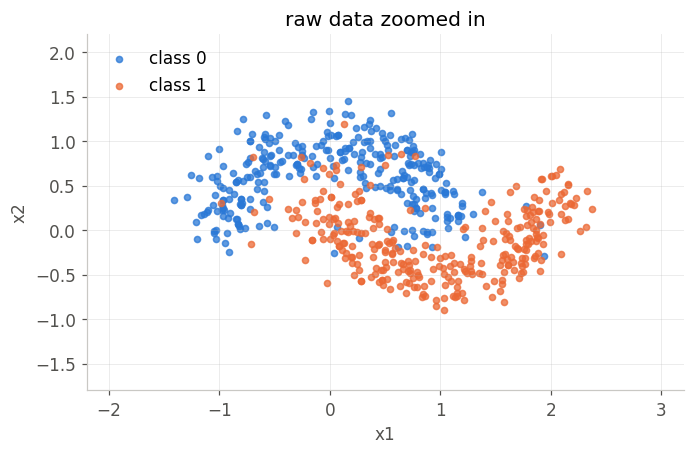

Data has been zoomed to where most points sit, but we have introduced some problems 1. Some rows are missing entirely from it (NaN), 2. some points are plotted twice, 3. There are outliers are sitting well outside this frame. 


In [12]:
fig, ax = plt.subplots()
plot_df = df.dropna(subset=["x1"])       # can't plot a point with a missing coordinate
for cls, color, name in [(0, C_CLASS0, "class 0"), (1, C_CLASS1, "class 1")]:
    sub = plot_df[plot_df.label == cls]
    ax.scatter(sub.x1, sub.x2, s=16, color=color, alpha=0.75, label=name)
ax.set(xlabel="x1", ylabel="x2", title="raw data zoomed in",
       xlim=(-2.2, 3.2), ylim=(-1.8, 2.2))
ax.legend(loc="upper left")
plt.show()

print("Data has been zoomed to where most points sit, but we have introduced some problems "
      "1. Some rows are missing entirely from it (NaN), 2. some points are plotted "
      "twice, 3. There are outliers are sitting well outside this frame. ")

---
# 2. Data curation

**Curation is deciding what should belong in the dataset**, before we decide how
to present it. This step can be critical to ensure our results are valid at all!

We check here for three specific issues (since we already know the data): exact duplicates, missing values, and outliers. 

In [16]:
print(f"rows                 : {len(df)}")
print(f"exact duplicate rows : {df.duplicated().sum()}")
print(f"missing x1 values    : {df['x1'].isna().sum()}")
print(df.describe().round(2))

rows                 : 610
exact duplicate rows : 0
missing x1 values    : 15
           x1      x2   label
count  595.00  610.00  610.00
mean     0.53    0.24    0.51
std      1.22    0.70    0.50
min     -7.13   -5.42    0.00
25%     -0.09   -0.17    0.00
50%      0.52    0.23    1.00
75%      1.12    0.69    1.00
max      7.53    5.24    1.00


## 2.1 Duplicates

One of the advantages of using `pandas` is that
exact duplicates for us. Otherwise, we would need to do this by hand.

In [15]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"removed {n_before - len(df)} duplicate rows -> {len(df)} rows remain")

removed 0 duplicate rows -> 610 rows remain


## 2.2 Missing values

Now that the duplicates are gone, `x1` is missing on a small number of rows. If we know what the data should be, we could fill it in ourselves, but the conservative approach is to drop the data. In real applications we need to be careful with the amount of data we drop. 

In general, whether dropping data or filling in the missing values, it is always important to describe the dataset being used.

In [17]:
n_before = len(df)
n_missing = df["x1"].isna().sum()
df = df.dropna().reset_index(drop=True)
print(f"dropped {n_missing} rows with a missing x1 ({n_missing / n_before:.1%} of the data) "
      f"-> {len(df)} rows remain")

dropped 15 rows with a missing x1 (2.5% of the data) -> 595 rows remain


## 2.3 Outliers

Sometimes data can have values which would greatly biase any regressor/classifier, but we need to detect those. An outlier detector needs a rule. We use as an example a **IQR rule**: a point is flagged on a feature if it
falls more than `k` interquartile ranges below $Q_1$ or above $Q_3$. `k = 3.0`. This is wide enough that ordinary spread from the `noise=0.20` in
our moons is not flagged, but tight enough to catch anything genuinely far away.
Always plot what you are about to throw out.

flagged 10 rows out of 595 as outliers


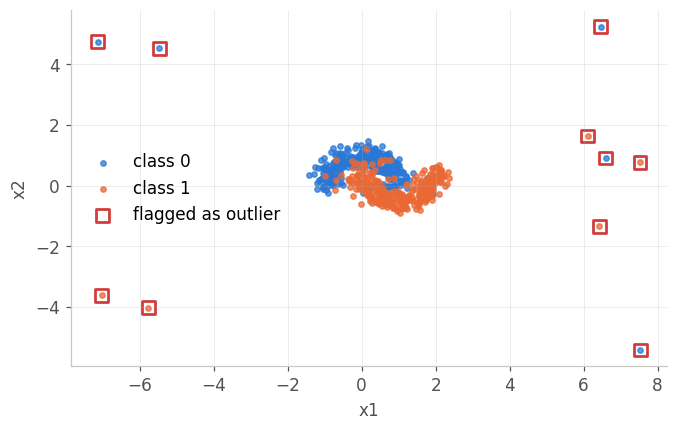


final clean dataset: 585 rows (started at 600, lost 15 genuine rows to missingness)


In [27]:
def iqr_flag(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    span = q3 - q1
    lo, hi = q1 - k * span, q3 + k * span
    return ~series.between(lo, hi)

is_outlier = iqr_flag(df.x1) | iqr_flag(df.x2)
print(f"flagged {is_outlier.sum()} rows out of {len(df)} as outliers")

fig, ax = plt.subplots()
for cls, color, name in [(0, C_CLASS0, "class 0"), (1, C_CLASS1, "class 1")]:
    sub = df[df.label == cls]
    ax.scatter(sub.x1, sub.x2, s=12, color=color, alpha=0.75, label=name)
ax.scatter(df[is_outlier].x1, df[is_outlier].x2,
           s=70, facecolors="none", edgecolors=C_FLAG, linewidths=1.8, marker="s",
           label="flagged as outlier")
ax.set(xlabel="x1", ylabel="x2")
ax.legend()
plt.show()

df_clean = df[~is_outlier].reset_index(drop=True)
print(f"\nfinal clean dataset: {len(df_clean)} rows "
      f"(started at {N_CLEAN}, lost {N_CLEAN - len(df_clean)} genuine rows to missingness)")

We have now curated the data to the best of our knowledge. We have removed the duplicates, the NaNs, and the outliers. However, our data remains noisy (we introduced this earlier on). We have no clear rule to define which data have been misclassified, as those points look just like the right ones. This noise is what becomes an **irreducible error floor**. The classifier cannot do better that a certain error without overfitting!

---
# 3. Preprocessing

Curation establishes *which data* belong in the dataset. Preprocessing sets *what
the model will use*. We also introduce the concept of **leakage**, where the model might do better than expected because it is receiving more information than we want.

## 3.1 Split the dataset

The train/validation/test split has to happen before any statistic is computed
from the data, even including the mean!
If that mean is computed on the full dataset, it has already absorbed a little
information about the validation and test rows. This is a **leak**, even though no label was involved. 

We use a 60 (train) / 20 (val) / 20 (test) split, **stratified** on the label so all three splits keep the same class balance.

Note that in practical applications we might be severely data limited, so we might need to compromise in our data splits.

In [29]:
X = df_clean[["x1", "x2"]].values.astype(np.float32)
y = df_clean["label"].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=0)

for name, Xs, ys in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:>5}: {len(Xs):4d} rows   class balance = {ys.mean():.2f}")

train:  351 rows   class balance = 0.51
  val:  117 rows   class balance = 0.51
 test:  117 rows   class balance = 0.50


## 3.2 Scale using train statistics only

Our two features are on comparable scales already, but that is not true in
general and gradient descent is sensitive to this: a feature with a huge range dominates the loss surface and needs a tiny learning rate, while the other barely moves. We standardize both features to zero mean, unit variance, **fit on `X_train`
only**, then apply that same transform to validation and test.

In [31]:
scaler = StandardScaler().fit(X_train)     # statistics come from train ONLY

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"train mean after scaling : {X_train_s.mean(axis=0).round(3)}  (should be ~0)")
print(f"train std  after scaling : {X_train_s.std(axis=0).round(3)}  (should be ~1)")
print(f"test  mean after scaling : {X_test_s.mean(axis=0).round(3)}  "
      f"(not exactly 0 - the test set wasn't used to fit the scaler, and that's correct)")

train mean after scaling : [0. 0.]  (should be ~0)
train std  after scaling : [1. 1.]  (should be ~1)
test  mean after scaling : [-0.054 -0.12 ]  (not exactly 0 - the test set wasn't used to fit the scaler, and that's correct)


## 3.3 The DataLoader

Everything is now a NumPy array. To train with mini-batch (small pieces of data at a time) gradient descent we need to repeatedly draw random, fixed-size slices of the training set, reshuffling every epoch (pass through the whole dataset), while the validation and test sets are only ever read through once. PyTorch's `Dataset` + `DataLoader` puts the data in a format that allows us for very efficient manipulation and training:

* a **`TensorDataset`** wraps matching tensors so that indexing `dataset[i]`
  returns the `i`-th `(features, label)` pair,
* a **`DataLoader`** wraps a dataset and hands out batches: shuffled for
  training, sequential for evaluation, and, on a real (large, disk-backed)
  dataset, would also load and preprocess the next batch in a background worker
  while the GPU is busy with the current one. On our few hundred in-memory rows
  that overlap doesn't matter, but the *interface* is the same one you would use
  on a million-row dataset. Moreover, many open datasets already come in this format.

In [32]:
def to_tensors(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

train_ds = TensorDataset(*to_tensors(X_train_s, y_train))
val_ds   = TensorDataset(*to_tensors(X_val_s, y_val))
test_ds  = TensorDataset(*to_tensors(X_test_s, y_test))

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # reshuffled every epoch
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)           # read once, in order
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"one training batch: features {tuple(xb.shape)}, labels {tuple(yb.shape)}")
print(f"{len(train_ds)} training rows / batch size {BATCH_SIZE} = {len(train_loader)} batches per epoch")

one training batch: features (32, 2), labels (32, 1)
351 training rows / batch size 32 = 11 batches per epoch


---
# 4. Baseline selection

Before we try to train a model, we need to know what can we expect to do using know methods. Here we take two simple baselines:

1. **Majority class.** Predict the more common label for every single point. If a
   trained model (where we spend resources) model can't clear this, something is not great.
2. **Logistic regression.** The simplest classifier. It provides one straight decision boundary. It tells us how much of the problem is "linearly separable".

Both are evaluated on **train and validation only**. The test set stays completely separated until the evaluation of the whole setup.

In [36]:
def accuracy(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

majority_class = 1 if y_train.mean() > 0.5 else 0
maj_train = accuracy(y_train, np.full_like(y_train, majority_class))
maj_val   = accuracy(y_val,   np.full_like(y_val, majority_class))

logreg = LogisticRegression().fit(X_train_s, y_train)
lr_train = accuracy(y_train, logreg.predict(X_train_s))
lr_val   = accuracy(y_val,   logreg.predict(X_val_s))

print(f"{'model':<22}{'train acc':>11}{'val acc':>10}")
print(f"{'majority class':<22}{maj_train:>11.3f}{maj_val:>10.3f}")
print(f"{'logistic regression':<22}{lr_train:>11.3f}{lr_val:>10.3f}")

model                   train acc   val acc
majority class              0.510     0.513
logistic regression         0.858     0.838


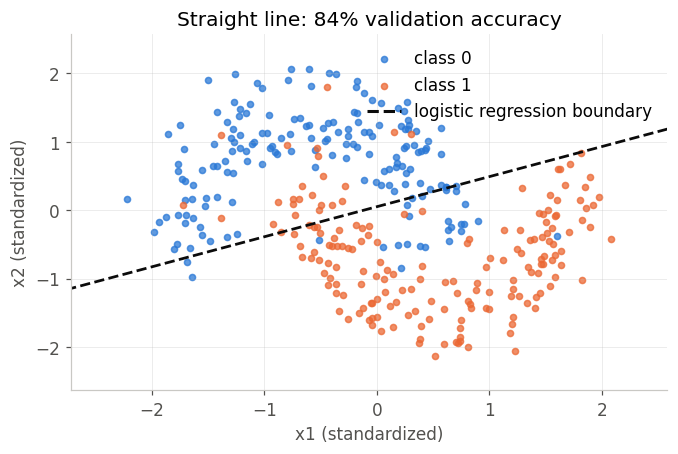

In [37]:
xg = np.linspace(X_train_s[:, 0].min() - 0.5, X_train_s[:, 0].max() + 0.5, 300)
yg = np.linspace(X_train_s[:, 1].min() - 0.5, X_train_s[:, 1].max() + 0.5, 300)
XG, YG = np.meshgrid(xg, yg)
grid = np.stack([XG.ravel(), YG.ravel()], axis=1)
prob = logreg.predict_proba(grid)[:, 1].reshape(XG.shape)

fig, ax = plt.subplots()
ax.contour(XG, YG, prob, levels=[0.5], colors=C_TRUTH, linestyles="--", linewidths=1.8)
for cls, color, name in [(0, C_CLASS0, "class 0"), (1, C_CLASS1, "class 1")]:
    mask = y_train == cls
    ax.scatter(X_train_s[mask, 0], X_train_s[mask, 1], s=16, color=color, alpha=0.75, label=name)
ax.plot([], [], color=C_TRUTH, ls="--", label="logistic regression boundary")
ax.set(xlabel="x1 (standardized)", ylabel="x2 (standardized)",
       title=f"Straight line: {lr_val:.0%} validation accuracy")
ax.legend()
plt.show()

The moons are built to interleave, so a single straight boundary necessarily cuts
through both crescents. The gap between the linear baseline and a curved classifier that can separate the data is what a nonlinear model can cover.

---
# 5. Model training

An MLP classifier looks almost exactly like the regression MLP from notebook 1:
same `Linear → activation → Linear` stack, swapping `tanh` for `ReLU` (a common
default for classification) and ending in a single logit rather than a real
value. `BCEWithLogitsLoss` combines a sigmoid with binary cross-entropy in one
numerically stable step.

The training loop below runs over the **`DataLoader`** from Part 3 and then uses the same `forward / loss / zero_grad / backward / step` steps from notebook 1, we repeat once per mini-batch instead of once per epoch.

In [ ]:
def make_classifier(width=16, depth=2, seed=0):
    torch.manual_seed(seed)
    layers = [nn.Linear(2, width), nn.ReLU()]
    for _ in range(depth - 1):
        layers += [nn.Linear(width, width), nn.ReLU()]
    layers += [nn.Linear(width, 1)]
    return nn.Sequential(*layers)


def run_epoch(model, loader, loss_fn, opt=None):
    # One pass over `loader`. Trains if `opt` is given, else just evaluates.
    training = opt is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = loss_fn(logits, yb)
        if training:
            opt.zero_grad()
            loss.backward()
            opt.step()
        total_loss += loss.item() * len(xb)
        correct += ((logits > 0) == (yb > 0.5)).sum().item()
        n += len(xb)
    return total_loss / n, correct / n

loss_fn = nn.BCEWithLogitsLoss()
model = make_classifier()
opt = torch.optim.Adam(model.parameters(), lr=0.02)

EPOCHS = 80
hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for epoch in range(EPOCHS):
    tl, ta = run_epoch(model, train_loader, loss_fn, opt)
    vl, va = run_epoch(model, val_loader, loss_fn)
    for k, v in zip(hist, (tl, vl, ta, va)):
        hist[k].append(v)

print(f"epoch {EPOCHS:3d}   train loss {hist['train_loss'][-1]:.4f}  acc {hist['train_acc'][-1]:.3f}"
      f"   |   val loss {hist['val_loss'][-1]:.4f}  acc {hist['val_acc'][-1]:.3f}")

epoch  80   train loss 0.1668  acc 0.954   |   val loss 0.3023  acc 0.915


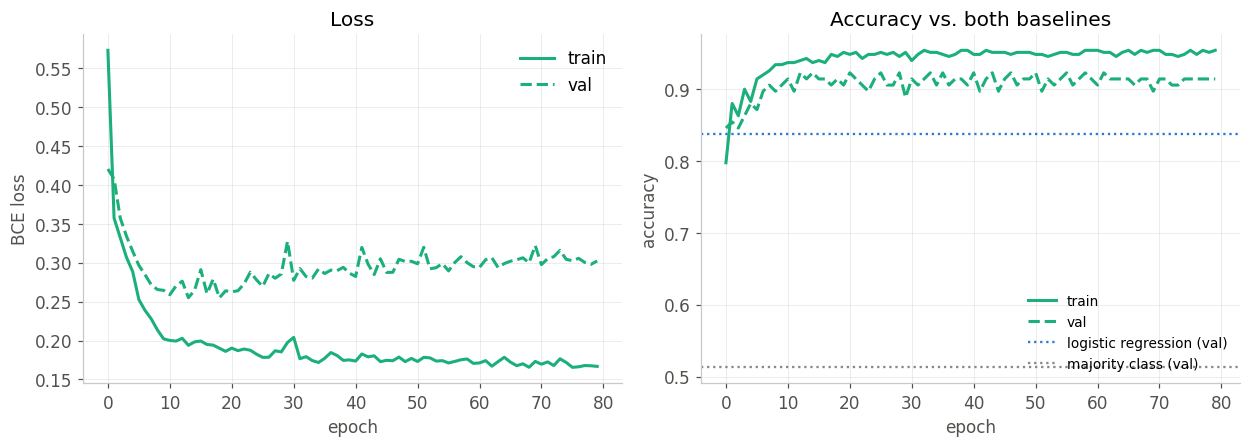

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax1.plot(hist["train_loss"], color=C_MLP, label="train")
ax1.plot(hist["val_loss"], color=C_MLP, ls="--", label="val")
ax1.set(xlabel="epoch", ylabel="BCE loss", title="Loss")
ax1.legend()

ax2.plot(hist["train_acc"], color=C_MLP, label="train")
ax2.plot(hist["val_acc"], color=C_MLP, ls="--", label="val")
ax2.axhline(lr_val, color=C_LOGREG, ls=":", lw=1.5, label="logistic regression (val)")
ax2.axhline(maj_val, color=C_MAJORITY, ls=":", lw=1.5, label="majority class (val)")
ax2.set(xlabel="epoch", ylabel="accuracy", title="Accuracy vs. both baselines")
ax2.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

The MLP clears the linear baseline within the first few epochs and then spends
the rest of training squeezing out the last few points of accuracy. We use a
constant learning rate, so "squeezing" gets slow and noisy. This allows us to introduce the idea of an scheduler

---
# 6. Learning rate schedulers

We have briefly talked about learning rates (the steps taken by the optimisation algorithm), where too high a learning rate overshoots and too low crawls. A **scheduler** resolves it by changing the learning rate over
the course of training. The
usual approach is: **large steps early**, while the model is far from any minimum
and we want speed, **small steps late**, to settle precisely instead of
bouncing around.

We compare four options, training the *same* initialization from the *same* seed
each time so the only difference is the learning-rate schedule:

* **constant**: the Part 5 baseline for comparison.
* **`StepLR`**: multiply the learning rate by `gamma` every `step_size` epochs. This is simple and can be hand-tuned.
* **`CosineAnnealingLR`**: glide the learning rate from its initial value down
  to (near) zero along a cosine curve. No sudden jumps, no extra hyperparameter
  beyond the total epoch count.
* **`ReduceLROnPlateau`**: this doesn't follow a fixed schedule
  at all. It watches the **validation loss** and only cuts the learning rate once
  that metric stops improving for `patience` epochs. This reacts to how training is actually going.

In [46]:
def train_with_schedule(make_scheduler, epochs=60, lr0=0.05, seed=0):
    # make_scheduler(opt) -> scheduler or None. Returns per-epoch LR and val loss.
    torch.manual_seed(seed)
    model = make_classifier(seed=seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr0)
    sched = make_scheduler(opt)

    lrs, val_losses = [], []
    for epoch in range(epochs):
        lrs.append(opt.param_groups[0]["lr"])
        run_epoch(model, train_loader, loss_fn, opt)
        vl, _ = run_epoch(model, val_loader, loss_fn)
        val_losses.append(vl)
        if sched is not None:
            if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
                sched.step(vl)
            else:
                sched.step()
    return np.array(lrs), np.array(val_losses)


EPOCHS_SWEEP = 60
schedules = {
    "constant": lambda opt: None,
    "StepLR":   lambda opt: torch.optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5),
    "Cosine":   lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_SWEEP),
    "Plateau":  lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5),
}

results = {name: train_with_schedule(fn, epochs=EPOCHS_SWEEP) for name, fn in schedules.items()}

print(f"{'schedule':<10}{'final val loss':>16}{'best val loss':>16}")
for name, (lrs, vls) in results.items():
    print(f"{name:<10}{vls[-1]:>16.4f}{vls.min():>16.4f}")

schedule    final val loss   best val loss
constant            0.3369          0.2590
StepLR              0.3358          0.2590
Cosine              0.3201          0.2593
Plateau             0.3049          0.2590


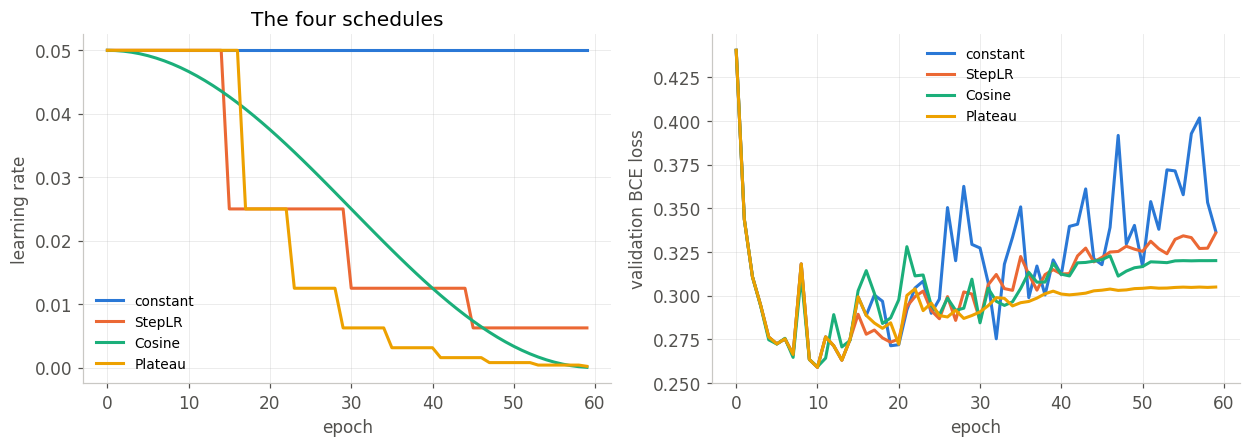

In [48]:
colors = {"constant": C_CONST, "StepLR": C_STEP, "Cosine": C_COS, "Plateau": C_PLATEAU}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
for name, (lrs, vls) in results.items():
    ax1.plot(lrs, color=colors[name], label=name)
    ax2.plot(vls, color=colors[name], label=name)
ax1.set(xlabel="epoch", ylabel="learning rate", title="The four schedules")
ax1.legend(fontsize=9)
ax2.set(xlabel="epoch", ylabel="validation BCE loss")
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

For the first ~15 epochs all four are
identical since none has cut the learning rate yet, so there is nothing to
distinguish them. After that, **constant** (blue) has a loss keeps
finding new lows early (it's briefly the *best* of all four, around epoch 20)
but then drifts upward and gets visibly noisy, spiking above 0.40 by the end.
This learning is quite unstable.
Nothing is slowing it down, so once it's close to a minimum it starts
overshooting back and forth across it.

The three schedules that actually decay the learning rate all stay close to
their own best value instead of wandering away from it (note though
that we find several optima) `ReduceLROnPlateau`
edges out the other two here. This makes sense since it checks the validation loss
 *before* deciding to cut.

**The practical takeaway:** Stopping a noisy constant-LR run at the "best" epoch is
gambling on a lucky spike (it might be just the best for this particular data). 
On the other hand, stopping a decayed run is reading a curve that has
actually settled.

---
# 7. Early stopping and checkpointing

A schedule controls the learning rate, but it doesn't tell us when to stop training. 
Left running long enough, our MLP has enough capacity to start overfitting.

**Early stopping** watches the validation loss and remembers the best model seen
so far. If that metric hasn't improved in `patience` epochs, training stops and
the best checkpoint (not the final, possibly-overfit one) is what we keep. This
is also our first use of **checkpointing**: periodically saving model weights so
the best version survives even after training moves past it. Note that taking the best 
model instead of the last is standard practice.

We carry `ReduceLROnPlateau` forward from Part 6 and pair it with early stopping. The two solve related but
different problems: the scheduler decides *how big a step to take*, early
stopping decides *when to stop taking them*. Running a scheduler and early stopping is good practice.

In [49]:
import copy

class EarlyStopper:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss = float("inf")
        self.best_epoch = -1
        self.best_state = None
        self.bad_epochs = 0

    def step(self, val_loss, epoch, model):
        # Returns True if training should stop now.
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.best_epoch = val_loss, epoch
            self.best_state = copy.deepcopy(model.state_dict())
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
        return self.bad_epochs >= self.patience


MAX_EPOCHS = 200
torch.manual_seed(0)
final_model = make_classifier(seed=0)
final_opt = torch.optim.Adam(final_model.parameters(), lr=0.05)
final_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(final_opt, factor=0.5, patience=5)
stopper = EarlyStopper(patience=15)

final_hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
stopped_at = MAX_EPOCHS
for epoch in range(MAX_EPOCHS):
    tl, ta = run_epoch(final_model, train_loader, loss_fn, final_opt)
    vl, va = run_epoch(final_model, val_loader, loss_fn)
    final_sched.step(vl)
    for k, v in zip(final_hist, (tl, vl, ta, va)):
        final_hist[k].append(v)
    if stopper.step(vl, epoch, final_model):
        stopped_at = epoch + 1
        break

final_model.load_state_dict(stopper.best_state)   # roll back to the best checkpoint
print(f"stopped at epoch {stopped_at} (of {MAX_EPOCHS} allowed)")
print(f"best validation loss {stopper.best_loss:.4f} at epoch {stopper.best_epoch}")

stopped at epoch 26 (of 200 allowed)
best validation loss 0.2590 at epoch 10


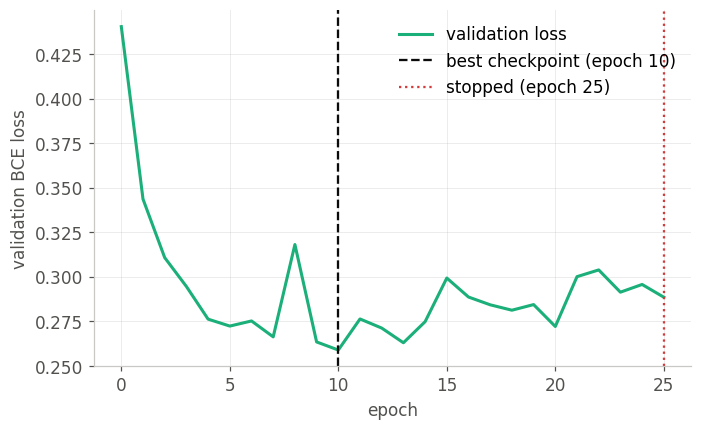

In [51]:
fig, ax = plt.subplots()
ax.plot(final_hist["val_loss"], color=C_MLP, label="validation loss")
ax.axvline(stopper.best_epoch, color=C_TRUTH, ls="--", lw=1.5,
           label=f"best checkpoint (epoch {stopper.best_epoch})")
ax.axvline(stopped_at - 1, color=C_FLAG, ls=":", lw=1.5, label=f"stopped (epoch {stopped_at - 1})")
ax.set(xlabel="epoch", ylabel="validation BCE loss")
ax.legend()
plt.show()

---
# 8. Evaluation

This is the only time we will consider `X_test` /
`y_test`. Every model gets scored on it.

In [55]:
maj_test = accuracy(y_test, np.full_like(y_test, majority_class))
lr_test  = accuracy(y_test, logreg.predict(X_test_s))
mlp_test_loss, mlp_test_acc = run_epoch(final_model, test_loader, loss_fn)

print(f"{'model':<22}{'test accuracy':>15}")
print(f"{'majority class':<22}{maj_test:>15.3f}")
print(f"{'logistic regression':<22}{lr_test:>15.3f}")
print(f"{'MLP (this notebook)':<22}{mlp_test_acc:>15.3f}")
print(f"\n(recall ~4% of labels were deliberately corrupted and survive curation. "
      f"no classifier on this dataset should land at 1.000)")

model                   test accuracy
majority class                  0.504
logistic regression             0.846
MLP (this notebook)             0.906

(recall ~4% of labels were deliberately corrupted and survive curation. no classifier on this dataset should land at 1.000)


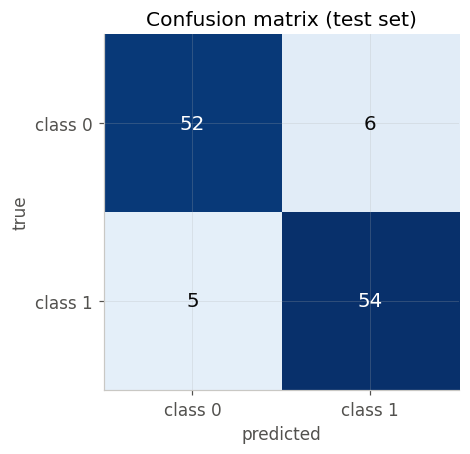

In [56]:
final_model.eval()
with torch.no_grad():
    test_logits = final_model(torch.tensor(X_test_s, dtype=torch.float32))
test_pred = (test_logits.numpy().ravel() > 0).astype(int)

cm = confusion_matrix(y_test.astype(int), test_pred)

fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues", vmin=0)
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "#0b0b0b"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=13)
ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="predicted", ylabel="true",
       title="Confusion matrix (test set)")
ax.set_xticklabels(["class 0", "class 1"]); ax.set_yticklabels(["class 0", "class 1"])
plt.show()

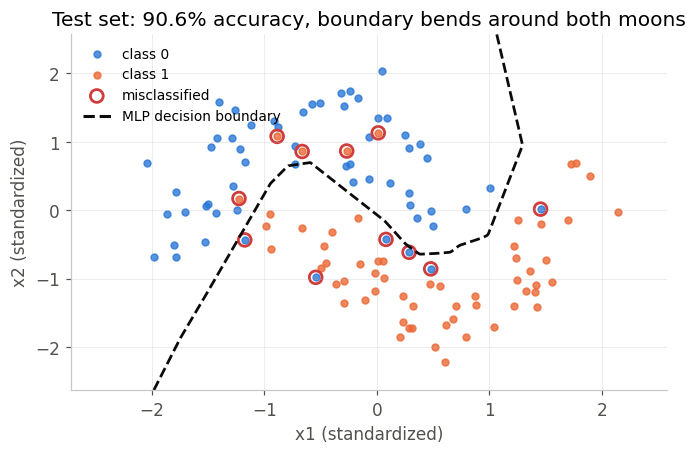

In [58]:
prob_grid = torch.sigmoid(
    final_model(torch.tensor(grid, dtype=torch.float32))
).detach().numpy().reshape(XG.shape)
misclassified = test_pred != y_test.astype(int)

fig, ax = plt.subplots()
ax.contour(XG, YG, prob_grid, levels=[0.5], colors=C_TRUTH, linestyles="--", linewidths=1.8)
for cls, color, name in [(0, C_CLASS0, "class 0"), (1, C_CLASS1, "class 1")]:
    mask = (y_test.astype(int) == cls) 
    ax.scatter(X_test_s[mask, 0], X_test_s[mask, 1], s=20, color=color, alpha=0.8, label=name)
ax.scatter(X_test_s[misclassified, 0], X_test_s[misclassified, 1], s=70,
           facecolors="none", edgecolors=C_FLAG, linewidths=1.8,
           label="misclassified")
ax.plot([], [], color=C_TRUTH, ls="--", label="MLP decision boundary")
ax.set(xlabel="x1 (standardized)", ylabel="x2 (standardized)",
       title=f"Test set: {mlp_test_acc:.1%} accuracy, boundary bends around both moons")
ax.legend(loc="upper left", fontsize=9)
plt.show()